In [13]:
import torch.nn as nn
import torch
import pandas as pd

In [14]:
data = pd.read_csv("Pokemon.csv")
data.head()


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Descripción de la tarea

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### Explicación del dataset
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

El dataset contiene información de 800 Pokémon descritos en 13 columnas, donde representa al Pokemón junto a sus caracteristocas, como el nombre, tipo, generación, estadísticas de combate y si es o no Legendary. 

La variable objetivo será `Legendary`, la cual indica si el Pokemón es legendario (True) o no legendario (False). Como solo son los clases posibles, diremos que el problema corresponde a una clasificación binaria supervisada. Pero para el entrenamiento cambiaremos las variables de False a 0 y el de True a 1.

Las columnas principales son:
|||
| --- | --- |
|`#`| Identificador numérico del Pokémon.|
|`Name`| Nombre del Pokémon.|
|`Type 1`| Tipo principal del Pokémon. (Grass, Fire, Water, etc.)
|`Type 2`| Tipo secundario. 386 Pokémon no poseen el segundo tipo.
|`Total`| Suma total de sus estadísticas base.
|`HP`| Puntos de vida.
|`Attack`| Ataque físico.
|`Defense`| Defensa física.
|`Sp. Atk`| Ataque especial.
|`Sp. Def`| Defensa especial.
|`Speed`| Velocidad.
|`Generation`| Generación a la que pertenece.
|`Legendary`| Variable booleana que indica si el Pokémon es legendario (`True`) o no (`False`).

El dataset presenta un desbalance en la cantidad de no legendarios en comparación con los legendarios que solo serían 65 de 800 Pokemón. Por esta razón no usaremos como métrica de evaluación el accuracy, sino que usaremos el F1-score, el cual es una métrica que combina la precisión y el recall, y es especialmente útil en estos casos de clases desbalanceadas. 



### Preparación del dataset

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

Para entrenar el modelo se seleccionan columnas numéricas relacionadas con las estadísticas de combate. 
La variable objetivo `Legendary` se transforma a valores numéricos:
- `False` → `0`: No legendario
- `True` → `1`: Legendario

Además, se separan los datos en entrenamiento, validación y prueba. La división se realiza con `stratify=y` para mantener una proporción similar de Pokémon legendarios y no legendarios en cada conjunto, debido al desbalance de clases.



In [15]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler

# 1. Cargar datos
df = pd.read_csv("Pokemon.csv")

# 2. Selección de características (Features) y Objetivo (Target)
# Seleccionamos las estadísticas numéricas que determinan si es fuerte/legendario
feature_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']
X_raw = df[feature_cols].values
y_raw = df['Legendary'].astype(int).values  # Convertimos True/False a 1/0

# 3. Escalado de datos (Justificación: Las redes neuronales convergen más rápido si los datos están en la misma escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 4. Creación del Dataset personalizado (Igual que en el tutorial)
class PokemonDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.long) # Usamos long para CrossEntropyLoss
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
        
    def __len__(self):
        return len(self.y)

dataset = PokemonDataset(X_scaled, y_raw)

# 5. División del dataset (60% entrenamiento, 20% validación, 20% prueba)
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, valid_set, test_set = random_split(
    dataset, [train_size, val_size, test_size], 
    generator=torch.Generator().manual_seed(42)
)

# 6. DataLoaders (Manejadores de minibatches)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print(f'Total batches - Train: {len(train_loader)}, Valid: {len(valid_loader)}, Test: {len(test_loader)}')


Total batches - Train: 15, Valid: 3, Test: 3


C:\Users\kathe\AppData\Local\Temp\ipykernel_3444\1189113852.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Legendary', data=df, palette='Set2')


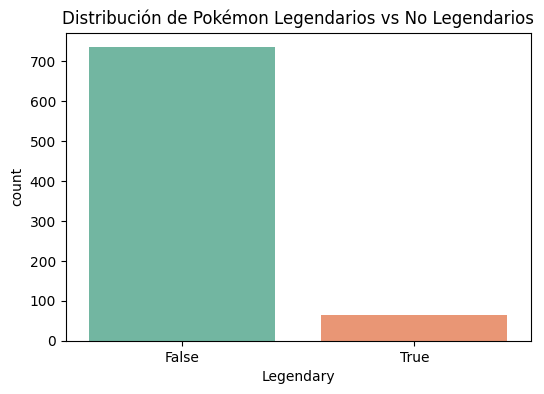

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de barras para ver el desbalance de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(x='Legendary', data=df, palette='Set2')
plt.title('Distribución de Pokémon Legendarios vs No Legendarios')
plt.show()

### Definición del modelo  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

## Definición del modelo

Para resolver el problema se utilizaron redes neuronales de tipo MLP (*Multilayer Perceptron*). Una MLP es una red neuronal completamente conectada, donde cada neurona de una capa se conecta con las neuronas de la siguiente capa. En este caso, el modelo recibe como entrada las características del Pokémon y entrega como salida una predicción entre dos clases: no legendario y legendario.

Se definieron tres arquitecturas con distinto nivel de complejidad. El primer modelo es una arquitectura simple sin capas ocultas, utilizada como línea base. El segundo modelo incorpora una capa oculta con activación ReLU, lo que permite aprender relaciones no lineales entre las variables. El tercer modelo contiene dos capas ocultas y una capa Dropout, lo que aumenta la capacidad del modelo y ayuda a reducir el sobreajuste durante el entrenamiento.

La capa de salida de los tres modelos tiene dos neuronas, correspondientes a las dos clases del problema: `0 = No legendario` y `1 = Legendario`. Por esta razón, se utiliza la función de pérdida `CrossEntropyLoss`, adecuada para problemas de clasificación multiclase o binaria representada con dos salidas.

In [17]:
from models import MLPClasificadorSimple, MLPClasificadorMedio, MLPClasificadorComplejo

modelo_simple = MLPClasificadorSimple(input_dim=7, output_dim=2)
modelo_medio = MLPClasificadorMedio(input_dim=7, output_dim=2)
modelo_complejo = MLPClasificadorComplejo(input_dim=7, output_dim=2)

print("Modelo simple:")
print(modelo_simple)

print("\nModelo medio:")
print(modelo_medio)

print("\nModelo complejo:")
print(modelo_complejo)


model = modelo_complejo

Modelo simple:
MLPClasificadorSimple(
  (output): Linear(in_features=7, out_features=2, bias=True)
)

Modelo medio:
MLPClasificadorMedio(
  (hidden): Linear(in_features=7, out_features=16, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=16, out_features=2, bias=True)
)

Modelo complejo:
MLPClasificadorComplejo(
  (layer1): Linear(in_features=7, out_features=32, bias=True)
  (act1): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (act2): ReLU()
  (output): Linear(in_features=16, out_features=2, bias=True)
)


### Definición de optimizador y función de costo  
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

In [18]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
print("Función de pérdida configurada.")


Función de pérdida configurada.


### Entrenamiento del modelo
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

El entrenamiento se realizó para las tres arquitecturas MLP definidas: simple, media y compleja. Cada modelo fue entrenado con el mismo conjunto de entrenamiento y evaluado en cada época usando el conjunto de validación.

Se utilizó la función de pérdida `CrossEntropyLoss`, ya que el problema corresponde a una clasificación con dos clases de salida: `No legendario` y `Legendario`. Los modelos entregan dos valores como salida, uno por cada clase, por lo que esta función de pérdida resulta adecuada.

Como optimizador se utilizó `Adam` con una tasa de aprendizaje de `0.005`. Este optimizador fue seleccionado por su eficiencia en el entrenamiento de redes neuronales y por ajustar los parámetros de forma adaptativa. El entrenamiento se realizó durante 20 épocas, utilizando un `batch size` de 32 para entrenamiento y de 64 para validación y prueba.

Durante el entrenamiento se registró la pérdida de entrenamiento y la pérdida de validación en cada época. La pérdida de validación se utilizó para guardar el mejor checkpoint de cada arquitectura. De esta forma, para cada modelo se conserva la versión que obtuvo el menor error de validación, evitando depender únicamente del último estado del entrenamiento.

Finalmente, los mejores checkpoints de las tres arquitecturas fueron comparados posteriormente en el conjunto de prueba mediante precision, recall y F1-score, priorizando las métricas asociadas a la identificación de Pokémon legendarios.


In [19]:
from tqdm import tqdm

def entrenar_modelo(modelo, train_loader, valid_loader, criterion, num_epochs=20, lr=0.005, model_name='modelo'):
    optimizer = optim.Adam(modelo.parameters(), lr=lr)
    train_losses = []  # esta lista almacenará la pérdida promedio de cada época para el conjunto de entrenamiento
    valid_losses = []  # esta lista almacenará la pérdida promedio de cada época para el conjunto de validación
    best_valid_loss = float('inf')
    best_epoch = -1
    best_path = f"best_{model_name}.pt"

    print(f"\nIniciando entrenamiento para {model_name}...")

    for epoch in tqdm(range(num_epochs)):
        # --- FASE DE ENTRENAMIENTO ---
        modelo.train()
        running_train_loss = 0.0
        

        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = modelo(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        
        train_losses.append(epoch_train_loss)

        # --- FASE DE VALIDACIÓN ---
        modelo.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for x_batch, y_batch in valid_loader:
                outputs = modelo(x_batch)
                loss = criterion(outputs, y_batch)

                running_val_loss += loss.item() * x_batch.size(0)

        epoch_val_loss = running_val_loss / len(valid_loader.dataset)
        
        valid_losses.append(epoch_val_loss)

         # Guardar mejor checkpoint del modelo según valid loss
        if epoch_val_loss < best_valid_loss:
            best_valid_loss = epoch_val_loss
            best_epoch = epoch + 1
            torch.save({
                'epoca': epoch + 1,
                'model_state_dict': modelo.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': epoch_val_loss
            }, best_path)

        if epoch % 10 == 0:
            print(f"Época {epoch+1:02d}/{num_epochs} -> "
                  f"Train Loss: {epoch_train_loss:.4f} || "
                  f"Val Loss: {epoch_val_loss:.4f} ")

    print(f"Mejor época para {model_name}: {best_epoch} con valid loss = {best_valid_loss:.4f}")
    print(f"Checkpoint guardado en: {best_path}")

    return {
        'model': modelo,
        'train_losses': train_losses,
        'valid_losses': valid_losses,
        'best_valid_loss': best_valid_loss,
        'best_epoch': best_epoch,
        'best_model_path': best_path
    }

modelos_a_comparar = {
    'simple': modelo_simple,
    'medio': modelo_medio,
    'complejo': modelo_complejo
}

resultados_modelos = {}
for nombre_modelo, modelo_actual in modelos_a_comparar.items():
    resultados_modelos[nombre_modelo] = entrenar_modelo(
        modelo_actual,
        train_loader,
        valid_loader,
        criterion,
        num_epochs=20,
        lr=0.005,
        model_name=nombre_modelo
    )




Iniciando entrenamiento para simple...


  0%|          | 0/20 [00:00<?, ?it/s]

Época 01/20 -> Train Loss: 0.6419 || Val Loss: 0.6104 


 45%|████▌     | 9/20 [00:00<00:00, 82.07it/s]

Época 11/20 -> Train Loss: 0.2756 || Val Loss: 0.2880 


...

Época 01/20 -> Train Loss: 0.3947 || Val Loss: 0.2400 


 30%|███       | 6/20 [00:00<00:00, 53.38it/s]

Época 11/20 -> Train Loss: 0.0765 || Val Loss: 0.1611 


100%|██████████| 20/20 [00:00<00:00, 56.53it/s]

Mejor época para complejo: 3 con valid loss = 0.1501
Checkpoint guardado en: best_complejo.pt


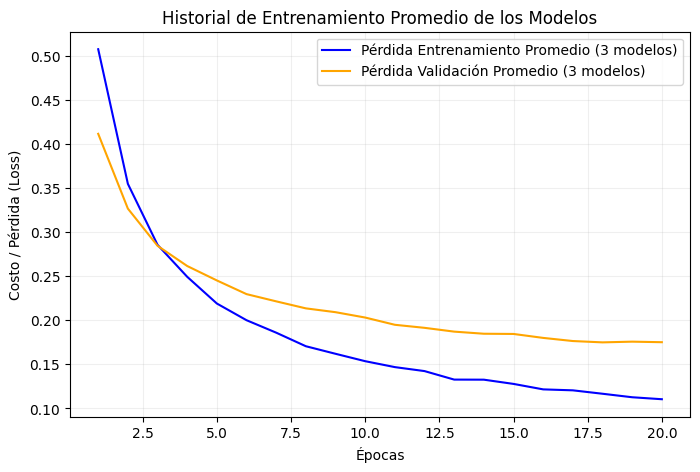

In [20]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, len(next(iter(resultados_modelos.values()))['train_losses']) + 1)

train_losses_promedio = np.mean(
    [resultado['train_losses'] for resultado in resultados_modelos.values()],
    axis=0
)
valid_losses_promedio = np.mean(
    [resultado['valid_losses'] for resultado in resultados_modelos.values()],
    axis=0
)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses_promedio, label='Pérdida Entrenamiento Promedio (3 modelos)', color='blue')
plt.plot(epochs, valid_losses_promedio, label='Pérdida Validación Promedio (3 modelos)', color='orange')
plt.title('Historial de Entrenamiento Promedio de los Modelos')
plt.xlabel('Épocas')
plt.ylabel('Costo / Pérdida (Loss)')
plt.legend()
plt.grid(alpha=0.2)
plt.savefig('curva_aprendizaje_promedio.png', bbox_inches='tight')
plt.show()

### Comparación de checkpoints por pérdida de validación
En la siguiente tabla podemos ver el mejor checkpoint alcanzado por cada arqutectura durante su propio entrenamiento

=== RESUMEN DE MEJORES CHECKPOINTS ===
     modelo  best_epoch  best_valid_loss
0    simple          20         0.216030
1     medio          11         0.135402
2  complejo           3         0.150078


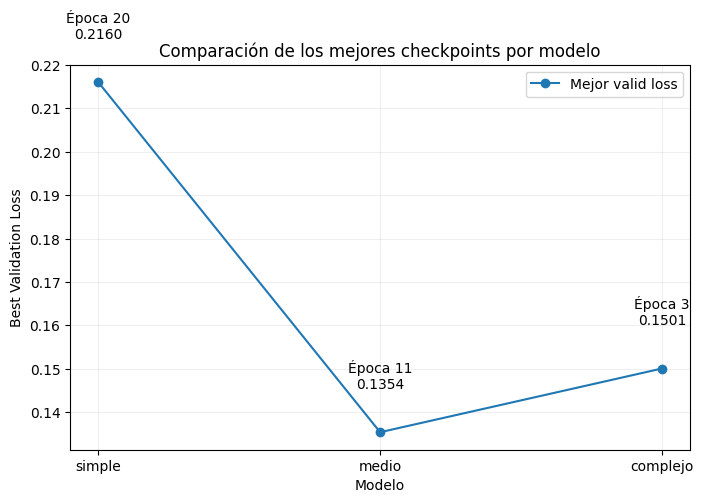

In [21]:
nombres_modelos = ['simple', 'medio', 'complejo']

best_valid_losses = [resultados_modelos[nombre]['best_valid_loss'] for nombre in nombres_modelos]
best_epochs = [resultados_modelos[nombre]['best_epoch'] for nombre in nombres_modelos]

resumen_checkpoints = pd.DataFrame({
    'modelo': nombres_modelos,
    'best_epoch': best_epochs,
    'best_valid_loss': best_valid_losses
})

print("=== RESUMEN DE MEJORES CHECKPOINTS ===")
print(resumen_checkpoints)

plt.figure(figsize=(8, 5))
plt.plot(nombres_modelos, best_valid_losses, marker='o', linestyle='-', label='Mejor valid loss')
plt.title('Comparación de los mejores checkpoints por modelo')
plt.xlabel('Modelo')
plt.ylabel('Best Validation Loss')
plt.grid(alpha=0.2)
plt.legend()

for x, y_val, epoca in zip(nombres_modelos, best_valid_losses, best_epochs):
    plt.text(x, y_val + 0.01, f'Época {epoca}\n{y_val:.4f}', ha='center')

plt.savefig('comparacion_mejores_checkpoints.png', bbox_inches='tight')
plt.show()

### Criterio de selección del modelo final

La pérdida de validación se utiliza para seleccionar el mejor checkpoint dentro del entrenamiento de cada arquitectura. Es decir, permite escoger la mejor versión de un mismo modelo a lo largo de sus épocas de entrenamiento.

Sin embargo, para escoger el modelo final entre las arquitecturas simple, media y compleja, se priorizan métricas asociadas al objetivo del problema. Como la tarea busca identificar Pokémon legendarios y el dataset está desbalanceado, se utiliza principalmente el **F1-score**, apoyado por **recall** y **precision** para identificar Pokémon legendarios.

Por esta razón, el modelo final no se selecciona necesariamente por tener la menor pérdida de validación, sino por presentar el mejor equilibrio entre detectar Pokémon legendarios reales y evitar predicciones incorrectas.

### Evaluación del modelo
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

Se evalúan los tres mejores checkpoints en el conjunto de prueba. No se utiliza `accuracy` como métrica principal debido al desbalance del dataset. Se consideran:

- `Precision`: de los Pokémon predichos como legendarios, cuántos realmente eran legendarios.
- `Recall`: de todos los Pokémon legendarios reales, cuántos detectó el modelo.
- `F1-score`: equilibrio entre precision y recall.

=== MÉTRICAS DE LOS 3 MODELOS EN TEST ===
     modelo  best_epoch  best_valid_loss  precision    recall  f1-score
0    simple          20         0.216030   0.571429  0.307692  0.400000
1     medio          11         0.135402   0.625000  0.384615  0.476190
2  complejo           3         0.150078   0.600000  0.461538  0.521739

=== MODELO SELECCIONADO ===
Modelo seleccionado: complejo
F1-score: 0.5217
Recall: 0.4615
Precision: 0.6
Best valid loss: 0.1501

Modelo final cargado correctamente: complejo


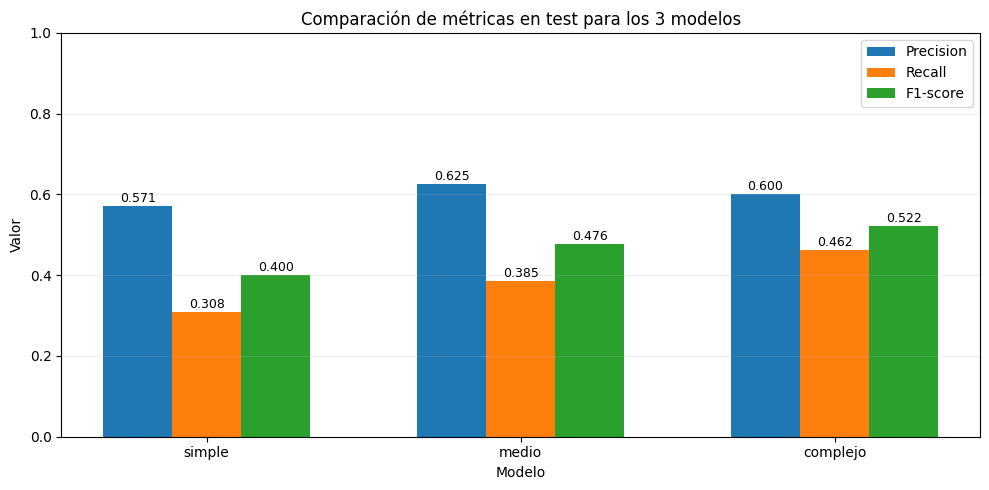

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Comparación de los 3 modelos en test

nombres_modelos = ['simple', 'medio', 'complejo']

precision_modelos = []
recall_modelos = []
f1_modelos = []

for nombre_modelo in nombres_modelos:
    info_modelo = resultados_modelos[nombre_modelo]

    checkpoint = torch.load(info_modelo['best_model_path'], map_location='cpu')

    modelo_eval = modelos_a_comparar[nombre_modelo]
    modelo_eval.load_state_dict(checkpoint['model_state_dict'])
    modelo_eval.eval()

    all_preds_metricas = []
    all_targets_metricas = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            outputs = modelo_eval(x_batch)

            # Como el modelo tiene 2 salidas:
            # salida 0 = No legendario
            # salida 1 = Legendario
            # Se escoge la clase con el valor más alto.
            _, preds = torch.max(outputs, 1)

            all_preds_metricas.extend(preds.numpy())
            all_targets_metricas.extend(y_batch.numpy())

    # Métricas enfocadas en la clase 1: Pokémon legendario
    precision_modelos.append(
        precision_score(
            all_targets_metricas,
            all_preds_metricas,
            pos_label=1,
            zero_division=0
        )
    )

    recall_modelos.append(
        recall_score(
            all_targets_metricas,
            all_preds_metricas,
            pos_label=1,
            zero_division=0
        )
    )

    f1_modelos.append(
        f1_score(
            all_targets_metricas,
            all_preds_metricas,
            pos_label=1,
            zero_division=0
        )
    )


# Tabla resumen de métricas
resumen_metricas_test = pd.DataFrame({
    'modelo': nombres_modelos,
    'best_epoch': [resultados_modelos[nombre]['best_epoch'] for nombre in nombres_modelos],
    'best_valid_loss': [resultados_modelos[nombre]['best_valid_loss'] for nombre in nombres_modelos],
    'precision': precision_modelos,
    'recall': recall_modelos,
    'f1-score': f1_modelos
})

print("=== MÉTRICAS DE LOS 3 MODELOS EN TEST ===")
print(resumen_metricas_test)

# Selección automática del mejor modelo
# Criterio:
# 1. Mayor F1-score
# 2. Si empatan, mayor recall
# 3. Si empatan, mayor precision
#
# Se usa F1-score primero porque equilibra precision y recall.
# Se usa recall como segundo criterio porque nos interesa detectar legendarios.

mejor_fila = resumen_metricas_test.sort_values(
    by=['f1-score', 'recall', 'precision'],
    ascending=False
).iloc[0]

mejor_nombre_modelo = mejor_fila['modelo']

print("\n=== MODELO SELECCIONADO ===")
print("Modelo seleccionado:", mejor_nombre_modelo)
print("F1-score:", round(mejor_fila['f1-score'], 4))
print("Recall:", round(mejor_fila['recall'], 4))
print("Precision:", round(mejor_fila['precision'], 4))
print("Best valid loss:", round(mejor_fila['best_valid_loss'], 4))

# Cargar el checkpoint del mejor modelo seleccionado
checkpoint = torch.load(
    resultados_modelos[mejor_nombre_modelo]['best_model_path'],
    map_location='cpu'
)

model = modelos_a_comparar[mejor_nombre_modelo]
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"\nModelo final cargado correctamente: {mejor_nombre_modelo}")

# Gráfico comparativo de métricas
x = np.arange(len(nombres_modelos))
ancho = 0.22

plt.figure(figsize=(10, 5))

plt.bar(x - ancho, precision_modelos, width=ancho, label='Precision')
plt.bar(x, recall_modelos, width=ancho, label='Recall')
plt.bar(x + ancho, f1_modelos, width=ancho, label='F1-score')

plt.xticks(x, nombres_modelos)
plt.ylim(0, 1)
plt.title('Comparación de métricas en test para los 3 modelos')
plt.xlabel('Modelo')
plt.ylabel('Valor')
plt.grid(axis='y', alpha=0.2)
plt.legend()

for i, valor in enumerate(precision_modelos):
    plt.text(i - ancho, valor + 0.01, f'{valor:.3f}', ha='center', fontsize=9)

for i, valor in enumerate(recall_modelos):
    plt.text(i, valor + 0.01, f'{valor:.3f}', ha='center', fontsize=9)

for i, valor in enumerate(f1_modelos):
    plt.text(i + ancho, valor + 0.01, f'{valor:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('metricas_test_comparacion_modelos.png', bbox_inches='tight')
plt.show()

### Curva de aprendizaje del modelo final

Luego de seleccionar el modelo final con las métricas de test, se muestra su curva de pérdida de entrenamiento y validación.

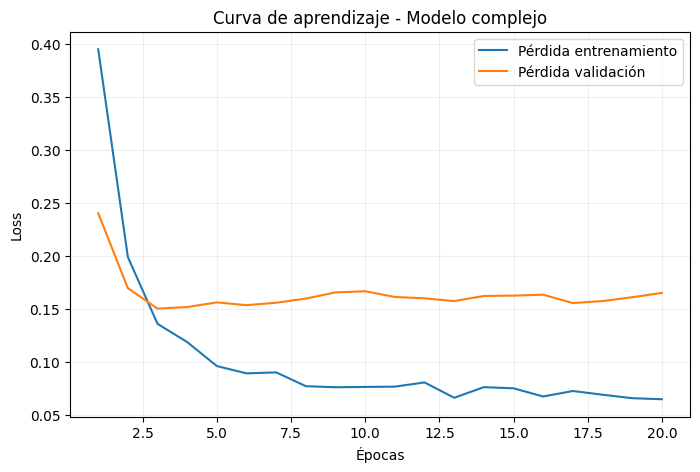

In [23]:
train_losses_final = resultados_modelos[mejor_nombre_modelo]['train_losses']
valid_losses_final = resultados_modelos[mejor_nombre_modelo]['valid_losses']

epochs = range(1, len(train_losses_final) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses_final, label='Pérdida entrenamiento')
plt.plot(epochs, valid_losses_final, label='Pérdida validación')
plt.title(f'Curva de aprendizaje - Modelo {mejor_nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.2)
plt.savefig(f'curva_aprendizaje_{mejor_nombre_modelo}.png', bbox_inches='tight')
plt.show()

### Evaluación final del modelo seleccionado

La siguiente celda evalúa únicamente el modelo seleccionado automáticamente según el criterio definido anteriormente.

Modelo final evaluado: complejo
Checkpoint cargado desde la época: 3
Pérdida de validación del checkpoint: 0.1501
=== MATRIZ DE CONFUSIÓN BÁSICA ===
[[143   4]
 [  7   6]]

=== REPORTE DE CLASIFICACIÓN ===
               precision    recall  f1-score   support

No Legendario       0.95      0.97      0.96       147
   Legendario       0.60      0.46      0.52        13

     accuracy                           0.93       160
    macro avg       0.78      0.72      0.74       160
 weighted avg       0.92      0.93      0.93       160



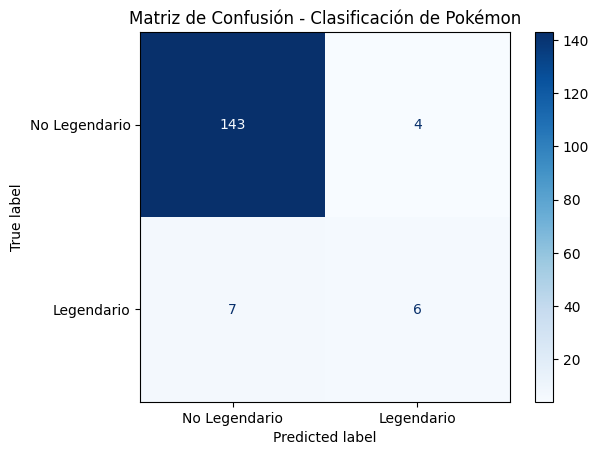

In [24]:
import os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#definir best_model_path para cargar el checkpoint del mejor modelo
best_model_path = resultados_modelos[mejor_nombre_modelo]['best_model_path']

if os.path.exists(best_model_path):
    checkpoint = torch.load(resultados_modelos[mejor_nombre_modelo]['best_model_path'] , map_location='cpu')

    model = modelos_a_comparar[mejor_nombre_modelo]
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

print(f"Modelo final evaluado: {mejor_nombre_modelo}")
print(f"Checkpoint cargado desde la época: {checkpoint['epoca']}")
print(f"Pérdida de validación del checkpoint: {checkpoint['loss']:.4f}")

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.numpy())
        all_targets.extend(y_batch.numpy())

# 1. Imprimir Reporte en texto plano
print("=== MATRIZ DE CONFUSIÓN BÁSICA ===")
print(confusion_matrix(all_targets, all_preds))

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(all_targets, all_preds, target_names=['No Legendario', 'Legendario'], zero_division=0))

# 2. Desplegar la Matriz de Confusión Gráfica y Elegante
ConfusionMatrixDisplay.from_predictions(
    all_targets, 
    all_preds, 
    display_labels=['No Legendario', 'Legendario'], 
    cmap='Blues'
 )
plt.title('Matriz de Confusión - Clasificación de Pokémon')
plt.savefig(f'matriz_confusion_{mejor_nombre_modelo}.png', bbox_inches='tight')
plt.show()

Se revisa cuántos Pokémon legendarios y no legendarios quedaron en el conjunto de prueba.

In [25]:
# 1. Filtrar el DataFrame original usando los índices para aislar los 160 Pokémon
df_test_completo = df.iloc[indices_test].copy()

# 2. CONTAR CLASES: Calcular cuántos son legendarios y cuántos no en el Test
conteos = df_test_completo['Legendary'].value_counts()
comunes_test = conteos.get(False, 0)
legendarios_test = conteos.get(True, 0)

# 3. Mostrar el resumen estadístico de las clases del examen
print(f"Total de Pokémon seleccionados para el Test: {len(df_test_completo)}")
print(f"  -> Pokémon Comunes (No Legendarios): {comunes_test}")
print(f"  -> Pokémon Legendarios Verdaderos: {legendarios_test}\n")
print("=== LISTA DE LOS 160 POKÉMON EN EL CONJUNTO DE PRUEBA ===\n")

# Configurar Pandas para que muestre las 160 filas sin recortar la lista en pantalla
pd.set_option('display.max_rows', 160)

# Desplegar la lista ordenada por su ID original para facilitar el análisis
df_test_completo[['#', 'Name', 'Type 1', 'Type 2', 'Total', 'Legendary']].sort_index()

NameError: name 'indices_test' is not defined

In [ ]:
# 1. Filtrar el DataFrame original usando esos índices
df_test_pokemon = df.iloc[indices_test].copy()

# 2. Añadir la columna con las predicciones guardadas en la lista 'all_preds'
df_test_pokemon['Prediccion_Modelo'] = all_preds

# 3. Mapear los números (0 y 1) a texto legible
df_test_pokemon['Prediccion_Modelo'] = df_test_pokemon['Prediccion_Modelo'].map({0: 'No Legendario', 1: 'Legendario'})
df_test_pokemon['Real_Texto'] = df_test_pokemon['Legendary'].map({False: 'No Legendario', True: 'Legendario'})

# 4. Filtrar e imprimir únicamente los Pokémon donde el modelo se equivocó
df_errores = df_test_pokemon[df_test_pokemon['Prediccion_Modelo'] != df_test_pokemon['Real_Texto']]

print(f"Modelo analizado: {mejor_nombre_modelo}")

print(f"Total de errores encontrados en el grupo de prueba: {len(df_errores)}\n")
print("=== DETALLE DE POKÉMON MAL CLASIFICADOS ===")
df_errores[['Name', 'Total', 'HP', 'Attack', 'Defense', 'Real_Texto', 'Prediccion_Modelo']]

Modelo analizado: complejo
Total de errores encontrados en el grupo de prueba: 8

=== DETALLE DE POKÉMON MAL CLASIFICADOS ===


,Name,Total,HP,Attack,Defense,Real_Texto,Prediccion_Modelo
543,Regigigas,670,110,160,110,Legendario,No Legendario
414,Regirock,580,80,100,200,Legendario,No Legendario
705,ThundurusTherian Forme,580,79,105,70,Legendario,No Legendario
428,DeoxysNormal Forme,600,50,150,50,Legendario,No Legendario
715,MeloettaAria Forme,600,100,77,77,No Legendario,Legendario
549,Darkrai,600,70,90,90,Legendario,No Legendario
248,HoundoomMega Houndoom,600,75,90,90,No Legendario,Legendario
717,Genesect,600,71,120,95,No Legendario,Legendario


### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?

R: ****

2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.

R: ****

3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?

R: ****


### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.

R:  **Sí, se utilizó Chat GPT como herramienta.**

2. ¿En qué parte o partes de la tarea utilizó estas herramientas?

R: **La utilizamos como apoyo para comprender la estructura del problema, revisar la coherencia metodológica del entrenamiento, analizar la diferencia entre pérdida de validación y métricas de evaluación, y mejorar la redacción de las justificaciones. Además, para darle un orden a cada celda con el fin  de que sea más fácil de leer y entender.**

**Se utilizó para crear los modelos de las arquitecturas simple, media y compleja, adaptándolos a la estructura del tutorial y a los resultados obtenidos en el notebook.**

**También se utilizó para revisar posibles errores conceptuales, como la selección del mejor modelo, la interpretación de precision, recall y F1-score, y la explicación de la matriz de confusión.**
